<a href="https://colab.research.google.com/github/mani12-svg/Object-Detection/blob/main/objetect_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Transformers, PyTorch, and the Pillow image library
!pip install "transformers<5.0.0" torch Pillow

In [ ]:
from transformers import pipeline

print("Downloading the Object Detection AI... (This might take a minute or two)")

# 1. Create the visual recognition tool
# We tell the pipeline the task is "object-detection"
detector = pipeline("object-detection", model="facebook/detr-resnet-50")

print("Download complete! The AI is ready to see.")

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Download complete! The AI is ready to see.


--- AI Object Detector is Live! ---
Click the button below to upload a photograph (.jpg or .png)


Saving Bengaluru Traffic Advisory_ Vehicles partially___.jpg to Bengaluru Traffic Advisory_ Vehicles partially___ (1).jpg

Scanning 'Bengaluru Traffic Advisory_ Vehicles partially___ (1).jpg'... 👁️

--- AI Vision Report ---
Found: person (Confidence: 83.1%)
Found: person (Confidence: 76.9%)
Found: car (Confidence: 69.8%)
Found: person (Confidence: 85.2%)
Found: person (Confidence: 81.9%)
Found: train (Confidence: 80.6%)
Found: person (Confidence: 61.4%)
Found: car (Confidence: 98.0%)
Found: person (Confidence: 83.6%)
Found: person (Confidence: 79.1%)
Found: person (Confidence: 80.9%)
Found: person (Confidence: 64.5%)
Found: person (Confidence: 59.3%)
Found: person (Confidence: 77.5%)
Found: car (Confidence: 98.5%)
Found: car (Confidence: 97.8%)
Found: person (Confidence: 58.6%)
Found: car (Confidence: 92.4%)
Found: car (Confidence: 71.5%)
Found: person (Confidence: 82.5%)
Found: car (Confidence: 95.8%)
Found: person (Confidence: 77.4%)
Found: umbrella (Confidence: 94.3%)
Found: car (Co

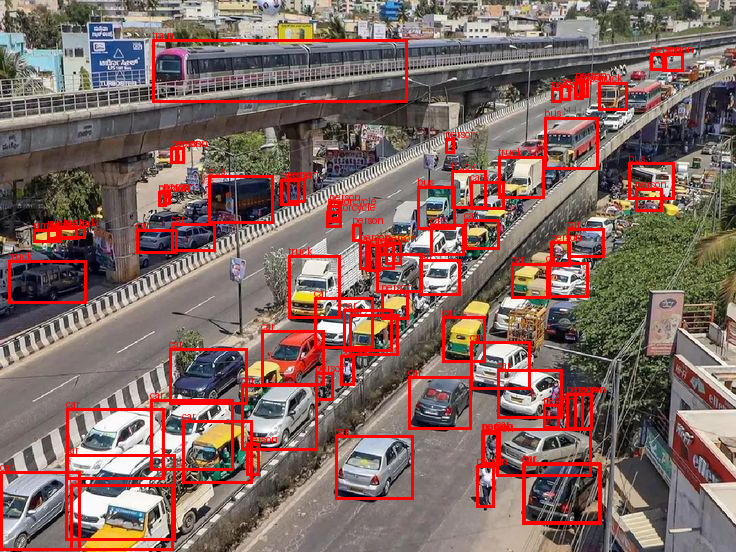

In [ ]:
from google.colab import files
from PIL import Image, ImageDraw
import io

print("--- AI Object Detector is Live! ---")
print("Click the button below to upload a photograph (.jpg or .png)")

# 1. Open a file picker for you to upload an image
uploaded = files.upload()

# 2. Process the uploaded image
for filename in uploaded.keys():
    print(f"\nScanning '{filename}'... 👁️")

    # Open the image file so the AI can process it
    image = Image.open(io.BytesIO(uploaded[filename]))

    # 3. The AI scans the image for objects
    results = detector(image)

    # 4. Print the text results
    print("\n--- AI Vision Report ---")
    if len(results) == 0:
        print("I didn't recognize any specific objects in this image.")
    else:
        for item in results:
            label = item['label']
            confidence = round(item['score'] * 100, 1) # Convert to a percentage
            print(f"Found: {label} (Confidence: {confidence}%)")

    # 5. Bonus: Draw boxes around what the AI found!
    draw = ImageDraw.Draw(image)
    for item in results:
        box = item['box']
        # Draw a bright red rectangle using the exact coordinates the AI provided
        draw.rectangle([box['xmin'], box['ymin'], box['xmax'], box['ymax']], outline="red", width=3)
        draw.text((box['xmin'], box['ymin'] - 10), item['label'], fill="red")

    # Show the final marked-up image right on your screen
    print("\n--- Visual Output ---")
    display(image)